In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/request_level_data.csv")

df.head()

,request_id,timestamp,scenario,endpoint_name,endpoint_path,payload_size,response_time_ms,status_code,active_requests,rps_10s,requests_last_60s,client_send_ts,client_receive_ts,client_observed_latency_ms
0,1,2026-04-18T14:40:11.827719,low,users,/api/users,316,192.81,200,1,0.1,1,2026-04-18T14:40:11.611374,2026-04-18T14:40:11.827719,213.20
1,2,2026-04-18T14:40:11.915110,low,search,/api/search,340,288.12,200,3,0.3,3,2026-04-18T14:40:11.611374,2026-04-18T14:40:11.915110,293.71
2,3,2026-04-18T14:40:11.733971,low,users,/api/users,296,104.07,200,2,0.2,2,2026-04-18T14:40:11.611374,2026-04-18T14:40:11.733971,112.62
3,4,2026-04-18T14:40:13.286060,low,orders,/api/orders,871,346.18,200,1,0.4,4,2026-04-18T14:40:12.915854,2026-04-18T14:40:13.286060,371.32
4,5,2026-04-18T14:40:13.254810,low,reports,/api/reports,387,314.19,200,2,0.5,5,2026-04-18T14:40:12.915854,2026-04-18T14:40:13.254810,339.68


## Veri Ön İşleme

Zaman bilgisi dönüştürülmüş ve veri kronolojik sıraya göre düzenlenmiştir.

In [2]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

## Feature Seçimi

Model girişinde sistem yükünü temsil eden değişkenler kullanılmıştır.
Tahmin edilecek değişken: response_time_ms

In [4]:
features = ["payload_size", "active_requests", "rps_10s", "requests_last_60s"]
target = "response_time_ms"

## Sliding Window Uygulaması

Zaman serisi verisi modele uygun hale getirilmiştir.

In [5]:
import numpy as np

def create_window(df, features, target, window_size):
    X, y = [], []
    
    for i in range(len(df) - window_size):
        X.append(df[features].iloc[i:i+window_size].values)
        y.append(df[target].iloc[i+window_size])
    
    return np.array(X), np.array(y)

window_size = 10

X, y = create_window(df, features, target, window_size)

In [7]:
## Veri Şekillendirme

In [8]:
X = X.reshape(X.shape[0], -1)

## Train-Test Ayrımı

In [9]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## Linear Regression Modeli

In [13]:
import sklearn
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## Random Forest Modeli

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Model Performans Değerlendirmesi

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

lr_results = evaluate(y_test, y_pred_lr)
rf_results = evaluate(y_test, y_pred_rf)

lr_results, rf_results

({'MAE': 134.2430227042312,
  'RMSE': np.float64(186.51025975415217),
  'R2': 0.12052966854973124},
 {'MAE': 122.77478641250678,
  'RMSE': np.float64(177.97922208346301),
  'R2': 0.19914415820024278})

## Tahmin Sonuçlarının Görselleştirilmesi

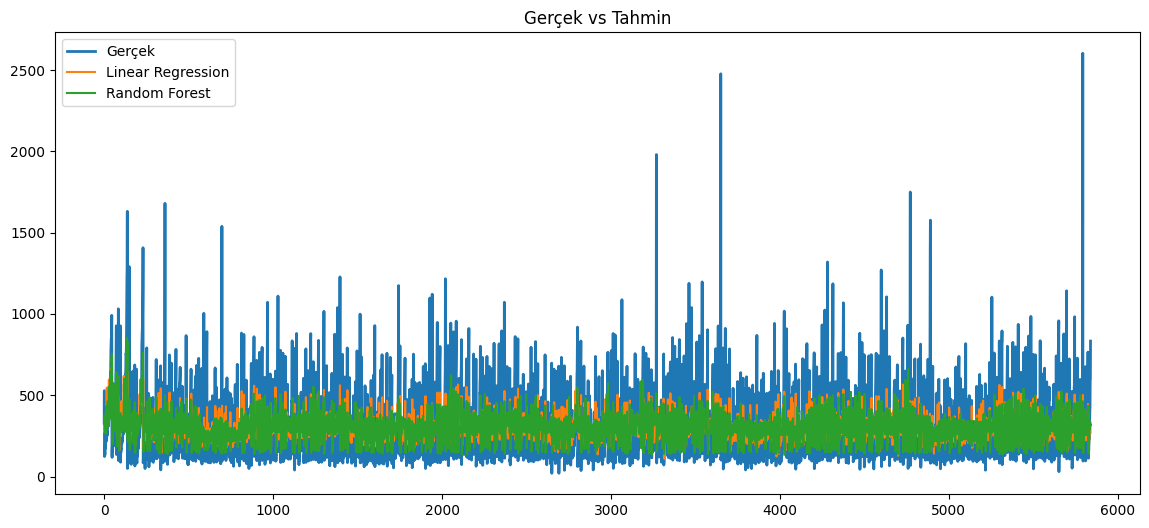

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(y_test, label="Gerçek", linewidth=2)
plt.plot(y_pred_lr, label="Linear Regression")
plt.plot(y_pred_rf, label="Random Forest")

plt.legend()
plt.title("Gerçek vs Tahmin")

plt.show()

Gerçek ve tahmin değerlerinin karşılaştırıldığı grafik incelendiğinde, modellerin genel trendi yakalayabildiği ancak ani yükselişleri (spike) tahmin etmekte yetersiz kaldığı görülmektedir. Özellikle yüksek gecikme değerlerinde model hatalarının arttığı gözlemlenmiştir.

### Model Kaydetme

In [23]:
import joblib

joblib.dump(rf, os.path.join(models_path, "random_forest_model.pkl"))
joblib.dump(lr, os.path.join(models_path, "linear_regression_model.pkl"))

['C:\\Users\\bahar\\source\\repos\\API-Analysis\\venv\\models\\linear_regression_model.pkl']

In [24]:
config = {
    "features": ["payload_size", "active_requests", "rps_10s", "requests_last_60s"],
    "target": "response_time_ms",
    "window_size": 10
}

joblib.dump(config, os.path.join(models_path, "model_config.pkl"))

['C:\\Users\\bahar\\source\\repos\\API-Analysis\\venv\\models\\model_config.pkl']